In [42]:
import os
import glob
from os import getcwd

import pandas as pd

In [43]:
os.getcwd()

'/Users/field/Desktop/CUNY/data_608/data_608_assignments/story5'

In [44]:
eventsFile = 'data/storm_events'
fatalitiesFile = 'data/fatalities'

In [45]:
csv_files = glob.glob(f"{eventsFile}/*.csv")
df_events = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)

/var/folders/5h/3qcv61l90gd0my3rpbjkj9jr0000gn/T/ipykernel_1293/4013596373.py:2: DtypeWarning: Columns (0: FLOOD_CAUSE, 1: TOR_OTHER_WFO, 2: TOR_OTHER_CZ_STATE, 3: TOR_OTHER_CZ_NAME) have mixed types. Specify dtype option on import or set low_memory=False.
  df_events = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)


In [46]:
csv_files = glob.glob(f"{fatalitiesFile}/*.csv")
df_fatalities = pd.concat([pd.read_csv(file) for file in csv_files], ignore_index=True)

In [47]:
df_fatalities

,FAT_YEARMONTH,FAT_DAY,FAT_TIME,FATALITY_ID,EVENT_ID,FATALITY_TYPE,FATALITY_DATE,FATALITY_AGE,FATALITY_SEX,FATALITY_LOCATION
0,200207,16,0,19702,5303355,D,07/16/2002 12:00:00,39.0,F,Permanent Home
1,200207,18,0,19703,5303355,D,07/18/2002 12:00:00,58.0,M,Permanent Home
2,200207,18,0,19704,5303355,D,07/18/2002 12:00:00,37.0,M,Permanent Home
3,200207,19,0,19705,5303355,D,07/19/2002 12:00:00,57.0,M,Permanent Home
4,200207,20,0,19706,5303355,D,07/20/2002 12:00:00,55.0,M,Permanent Home
...,...,...,...,...,...,...,...,...,...,...
21134,200306,16,0,20065,5361130,D,06/16/2003 12:00:00,16.0,M,Vehicle/Towed Trailer
21135,200311,27,0,20699,5328976,D,11/27/2003 12:00:00,56.0,F,Vehicle/Towed Trailer
21136,200312,2,0,20386,5331188,D,12/02/2003 12:00:00,56.0,M,Vehicle/Towed Trailer
21137,200312,5,0,20400,5328674,D,12/05/2003 12:00:00,61.0,M,Vehicle/Towed Trailer


In [48]:
df_events.columns

Index(['BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 'END_YEARMONTH',
       'END_DAY', 'END_TIME', 'EPISODE_ID', 'EVENT_ID', 'STATE', 'STATE_FIPS',
       'YEAR', 'MONTH_NAME', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME',
       'WFO', 'BEGIN_DATE_TIME', 'CZ_TIMEZONE', 'END_DATE_TIME',
       'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT',
       'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE',
       'MAGNITUDE', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'CATEGORY', 'TOR_F_SCALE',
       'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE',
       'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 'BEGIN_RANGE',
       'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH',
       'END_LOCATION', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON',
       'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE'],
      dtype='str')

In [49]:
df_events['EVENT_TYPE'].unique()

<ArrowStringArray>
[                      'Hail',          'Thunderstorm Wind',
                    'Tornado',             'Winter Weather',
                      'Flood',                'Flash Flood',
                  'Lightning',                    'Drought',
                   'Wildfire',                  'High Wind',
                'Strong Wind',                'Debris Flow',
               'Funnel Cloud',   'Marine Thunderstorm Wind',
                'Rip Current',               'Winter Storm',
                'Marine Hail',              'Coastal Flood',
                 'Heavy Snow',                  'Avalanche',
         'Marine Strong Wind',           'Marine High Wind',
                  'Dense Fog',                 'Heavy Rain',
                  'Ice Storm',      'Astronomical Low Tide',
            'Cold/Wind Chill',                 'Waterspout',
                  'High Surf',           'Lake-Effect Snow',
                 'Dust Storm', 'Marine Tropical Depression',
     

In [50]:
event_types =  ['Marine Hurricane/Typhoon', 'Hurricane (Typhoon)', 'Tornado']

In [51]:
df_events = df_events[df_events['EVENT_TYPE'].isin(event_types)]

In [52]:
df_events.sort_values(by=['BEGIN_YEARMONTH', 'BEGIN_DAY','EVENT_ID'], inplace=True)
df_events.reset_index(inplace=True)

In [53]:
df_events

,index,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,...,END_RANGE,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE
0,975480,200001,3,1405,200001,3,1405,1090502,5129129,INDIANA,...,3.00,N,FREDDRICKSBURG,NaN,NaN,NaN,NaN,NaN,A tornado touched down in Washington county no...,PDC
1,977837,200001,3,1330,200001,3,1340,1090549,5129620,MISSISSIPPI,...,5.00,E,WATER VLY,34.16667,-89.55000,34.23333,-89.55000,NaN,The tornado first developed just south of High...,PDC
2,977860,200001,3,1340,200001,3,1400,1090549,5129728,MISSISSIPPI,...,3.00,W,PARIS,34.18333,-89.51667,34.38333,-89.26667,NaN,The tornado first developed just south of High...,PDC
3,977514,200001,3,1400,200001,3,1410,1090549,5129729,MISSISSIPPI,...,4.00,SW,PINEDALE,34.38333,-89.25000,34.60000,-89.08333,NaN,The tornado first developed just south of High...,PDC
4,978353,200001,3,1215,200001,3,1218,1090744,5131031,MISSISSIPPI,...,1.00,SW,SCHLATER,33.63333,-90.36667,33.66667,-90.33333,NaN,This weak tornado nearly destroyed a mobile ho...,PDC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38891,185502,202512,28,1645,202512,28,1646,209460,1305604,ILLINOIS,...,1.88,SE,REDMON,39.63430,-87.84450,39.63480,-87.84080,The airmass continued to destabilize across ce...,Video evidence indicated that a tornado touche...,CSV
38892,185503,202512,28,1459,202512,28,1500,209460,1305605,ILLINOIS,...,3.20,SE,OSBERNVILLE,39.71440,-89.14210,39.71520,-89.14030,The airmass continued to destabilize across ce...,A storm spotter captured video of a tornado to...,CSV
38893,185692,202512,28,1500,202512,28,1530,209460,1305606,ILLINOIS,...,3.26,ENE,CASNER,39.71520,-89.14030,39.82270,-88.74610,The airmass continued to destabilize across ce...,This tornado crossed into far western Macon Co...,CSV
38894,185693,202512,28,1530,202512,28,1533,209460,1305607,ILLINOIS,...,1.80,NNW,LA PLACE,39.82270,-88.74610,39.82550,-88.72680,The airmass continued to destabilize across ce...,This tornado crossed into western Piatt County...,CSV


In [54]:
df_events['DEATHS_INDIRECT']

0        0
1        0
2        0
3        0
4        0
        ..
38891    0
38892    0
38893    0
38894    0
38895    0
Name: DEATHS_INDIRECT, Length: 38896, dtype: int64

In [55]:
global_temp = pd.DataFrame(pd.read_csv('data/NASA_global_mean_temp_anomaly.csv', skiprows=1))

In [56]:
global_temp = global_temp[global_temp['Year'] != 2026]

In [57]:
global_temp

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.25,-.09,-.16,-.10,-.21,-.18,-.10,-.14,-.23,-.22,-.19,-.17,***,***,-.12,-.17,-.20
1,1881,-0.20,-0.15,.02,.04,.07,-.19,.01,-.04,-.15,-.21,-.18,-.07,-.09,-.10,-.18,.04,-.07,-.18
2,1882,0.16,0.14,.04,-.16,-.14,-.23,-.16,-.08,-.15,-.23,-.17,-.36,-.11,-.09,.08,-.09,-.16,-.18
3,1883,-0.29,-0.36,-.12,-.18,-.18,-.07,-.08,-.14,-.22,-.11,-.24,-.12,-.18,-.20,-.34,-.16,-.10,-.19
4,1884,-0.13,-0.08,-.37,-.40,-.34,-.35,-.31,-.28,-.27,-.25,-.33,-.31,-.28,-.27,-.11,-.37,-.31,-.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,2021,0.81,0.64,.89,.76,.79,.85,.92,.81,.92,.98,.92,.87,.85,.84,.75,.81,.86,.94
142,2022,0.91,0.89,1.04,.83,.84,.92,.94,.94,.88,.97,.73,.79,.89,.90,.89,.90,.93,.86
143,2023,0.87,0.96,1.23,.99,.94,1.08,1.19,1.19,1.48,1.34,1.40,1.35,1.17,1.12,.88,1.05,1.15,1.41
144,2024,1.25,1.43,1.39,1.31,1.16,1.24,1.20,1.30,1.23,1.34,1.29,1.26,1.28,1.29,1.34,1.29,1.25,1.29


In [58]:
global_temp_drop = global_temp.drop(columns=['J-D','D-N','DJF','MAM','JJA','SON'])

In [59]:
global_temp_long = pd.melt(global_temp_drop, id_vars = 'Year' )
global_temp_long.rename(columns={'variable':'Month', 'value':'Anomaly'}, inplace=True)

In [60]:
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

In [61]:
global_temp_long['Month'] = pd.Categorical(global_temp_long['Month'], categories=month_order, ordered=True)
global_temp_long.sort_values(by = ['Year', 'Month'], inplace=True)
global_temp_long.reset_index(inplace=True)
global_temp_long.drop('index', axis=1)

,Year,Month,Anomaly
0,1880,Jan,-0.19
1,1880,Feb,-0.25
2,1880,Mar,-.09
3,1880,Apr,-.16
4,1880,May,-.10
...,...,...,...
1747,2025,Aug,1.17
1748,2025,Sep,1.25
1749,2025,Oct,1.19
1750,2025,Nov,1.21


In [62]:
global_temp_long.drop('Month', axis = 1, inplace = True)
global_temp_long.drop('index', axis = 1, inplace = True)

In [63]:
global_temp_long['Anomaly'] = pd.to_numeric(global_temp_long['Anomaly'])

In [64]:
global_temp_long

,Year,Anomaly
0,1880,-0.19
1,1880,-0.25
2,1880,-0.09
3,1880,-0.16
4,1880,-0.10
...,...,...
1747,2025,1.17
1748,2025,1.25
1749,2025,1.19
1750,2025,1.21


In [65]:
global_temp_average = global_temp_long.groupby(['Year']).mean().reset_index()

In [66]:
global_temp_average

,Year,Anomaly
0,1880,-0.171667
1,1881,-0.087500
2,1882,-0.111667
3,1883,-0.175833
4,1884,-0.285000
...,...,...
141,2021,0.846667
142,2022,0.890000
143,2023,1.168333
144,2024,1.283333


In [67]:
global_temp_average[-25:]

,Year,Anomaly
121,2001,0.530000
122,2002,0.625000
123,2003,0.613333
124,2004,0.526667
125,2005,0.674167
126,2006,0.637500
127,2007,0.662500
128,2008,0.538333
129,2009,0.651667
130,2010,0.720000


In [68]:
import plotly.express as px
import plotly.graph_objects  as go

In [69]:
years = list(global_temp_average['Year'])
temp_anomaly = list(global_temp_average['Anomaly'])

In [70]:
step = 2
frames = []
for i in range(1, len(years) + 1, step):
    frames.append(go.Frame(
        data = [go.Scatter(x=years[:i], y=temp_anomaly[:i])],
        name=str(years[i-1])
    ))

In [71]:
fig = go.Figure(
    data = [go.Scatter(x=years[:1], y = temp_anomaly[:1], mode='lines', line=dict(color='tomato', width=2))], frames=frames
)

In [72]:
fig.update_layout(
    updatemenus=[dict(
        type='buttons',
        buttons=[dict(label='Play',
                      method='animate',
                      args=[None, dict(frame=dict(duration=30, redraw=False),
                                       transition = dict(duration=0),
                                       fromcurrent=True)])]
    )],
    sliders=[dict(
        steps=[dict(method='animate', args=[[f.name]], label=f.name)
            for f in frames],
        currentvalue=dict(prefix='Year: ')
    )]
)

fig.write_html('temperature.html')

In [73]:
os.getcwd()

'/Users/field/Desktop/CUNY/data_608/data_608_assignments/story5'

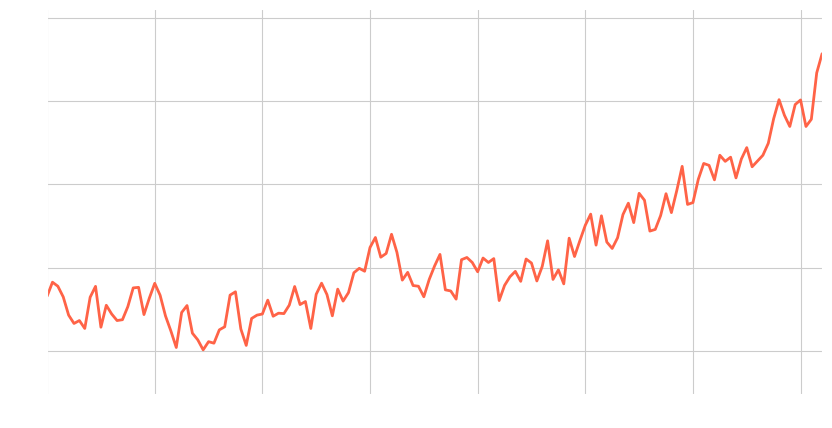

In [74]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(10,5))
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
line, = ax.plot([], [], color = 'tomato', linewidth = 2)
ax.set_xlim(1880, 2025)
ax.set_ylim(-0.5, 1.4)
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')

def update(frame):
    y_data = temp_anomaly[:frame]
    x_data = years[:frame]
    line.set_data(x_data, y_data)

    if frame > 1:
        min_y = min(y_data)
        max_y = max(y_data)
        pad = (max_y - min_y) * 0.15 or 0.1
        ax.set_ylim(min_y - pad, max_y + pad)
        ax.set_xlim(years[0], years[frame - 1])  # x axis grows too

    return line,

ani = animation.FuncAnimation(fig, update, frames=len(years), interval = 30, blit =True)
ani.save("temperature.mp4", writer="ffmpeg", fps = 30, savefig_kwargs={"transparent":True})
ani.save("temperature.gif", writer="pillow", fps=30)

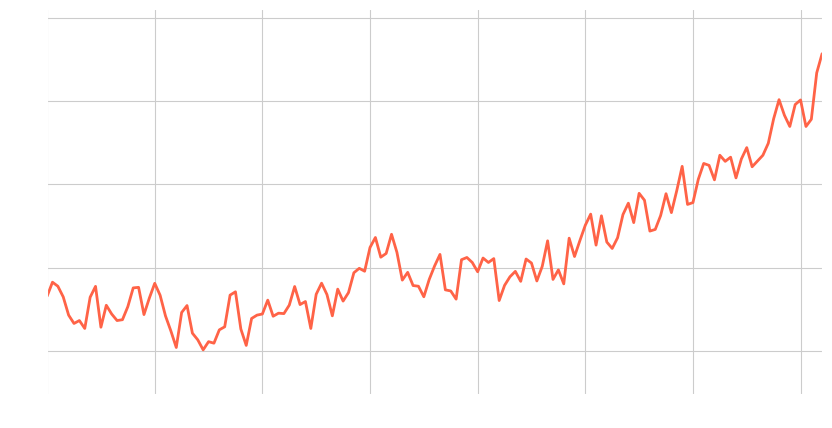

In [75]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_alpha(0)
ax.patch.set_alpha(0)
line, = ax.plot([], [], color='tomato', linewidth=2)
ax.set_xlim(1880, 2025)
ax.set_ylim(-0.5, 1.4)
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
for spine in ax.spines.values():
    spine.set_edgecolor('white')


def update(frame):
    y_data = temp_anomaly[:frame]
    x_data = years[:frame]
    line.set_data(x_data, y_data)

    if frame > 1:
        min_y = min(y_data)
        max_y = max(y_data)
        pad = (max_y - min_y) * 0.15 or 0.1
        ax.set_ylim(min_y - pad, max_y + pad)
        ax.set_xlim(years[0], years[frame - 1])  # x axis grows too

    return line,


ani = animation.FuncAnimation(fig, update, frames=len(years), interval=30, blit=True)
ani.save("temperature.mp4", writer="ffmpeg", fps=30, savefig_kwargs={"transparent": True})
ani.save("temperature.gif", writer="pillow", fps=30)

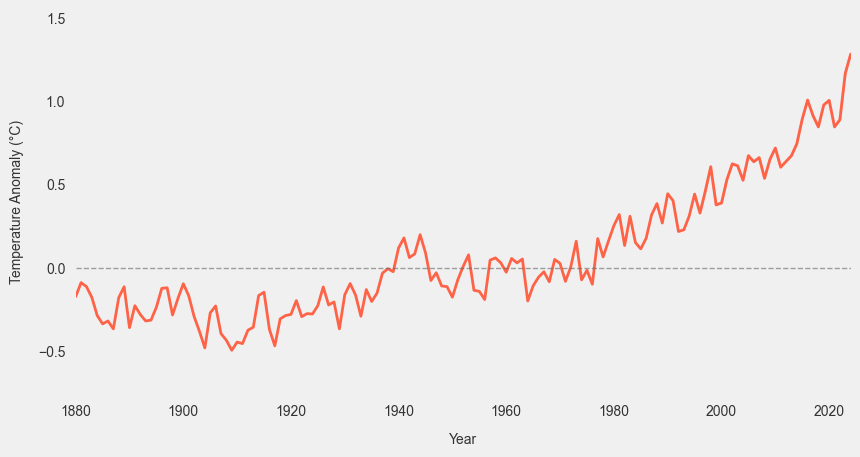

In [76]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))

# Light gray background
fig.patch.set_facecolor('#f0f0f0')
ax.set_facecolor('#f0f0f0')

# Remove gridlines
ax.grid(False)

# Main line
line, = ax.plot([], [], color='tomato', linewidth=2)

# Fading trail line
trail, = ax.plot([], [], color='tomato', linewidth=2, alpha=0.2)

ax.set_xlim(1880, 2025)
ax.set_ylim(-0.5, 1.4)

# Labels
ax.set_xlabel("Year", color='#333333', labelpad=10)
ax.set_ylabel("Temperature Anomaly (°C)", color='#333333', labelpad=10)

# Ticks
ax.tick_params(axis='x', colors='#333333', length=4)
ax.tick_params(axis='y', colors='#333333', length=4)
ax.set_xticks(range(1880, 2030, 20))

# Remove box (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Subtle zero baseline
ax.axhline(0, color='#666666', linewidth=1, linestyle='--', alpha=0.6)

def update(frame):
    y_data = temp_anomaly[:frame]
    x_data = years[:frame]

    # Main line (current)
    line.set_data(x_data, y_data)

    # Trail: show last N points fading
    trail_length = 30
    if frame > trail_length:
        trail_x = x_data[-trail_length:]
        trail_y = y_data[-trail_length:]
    else:
        trail_x = x_data
        trail_y = y_data

    trail.set_data(trail_x, trail_y)

    # Dynamic scaling
    if frame > 1:
        min_y = min(y_data)
        max_y = max(y_data)
        pad = (max_y - min_y) * 0.15 or 0.1
        ax.set_ylim(min_y - pad, max_y + pad)
        ax.set_xlim(years[0], years[frame - 1])

    return line, trail

ani = animation.FuncAnimation(
    fig, update, frames=len(years), interval=30, blit=True
)

ani.save("temperature.mp4", writer="ffmpeg", fps=30)

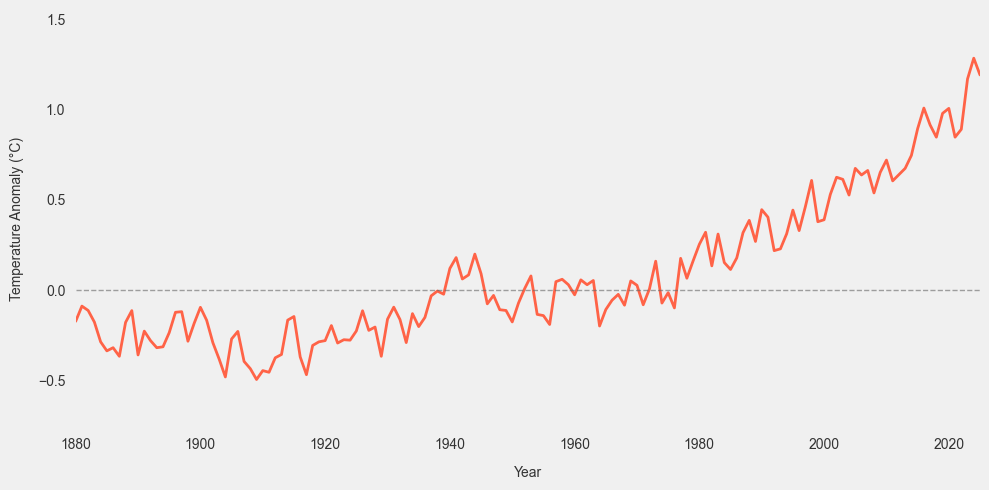

In [77]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

# Light gray background
fig.patch.set_facecolor('#f0f0f0')
ax.set_facecolor('#f0f0f0')

# Remove gridlines
ax.grid(False)

# Full data (final frame)
ax.plot(years, temp_anomaly, color='tomato', linewidth=2)

# Subtle zero baseline
ax.axhline(0, color='#666666', linewidth=1, linestyle='--', alpha=0.6)

# Labels
ax.set_xlabel("Year", color='#333333', labelpad=10)
ax.set_ylabel("Temperature Anomaly (°C)", color='#333333', labelpad=10)

# Ticks
ax.tick_params(axis='x', colors='#333333', length=4)
ax.tick_params(axis='y', colors='#333333', length=4)
ax.set_xticks(range(1880, 2030, 20))

# Remove box (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Set final limits (same logic as animation end)
min_y = min(temp_anomaly)
max_y = max(temp_anomaly)
pad = (max_y - min_y) * 0.15 or 0.1
ax.set_ylim(min_y - pad, max_y + pad)
ax.set_xlim(years[0], years[-1])

plt.tight_layout()
plt.savefig("temperature_static.png", dpi=300)
plt.show()

In [78]:
df_events["Year"] = df_events["BEGIN_YEARMONTH"].astype(str).str[0:4]

In [79]:
df_events.columns

Index(['index', 'BEGIN_YEARMONTH', 'BEGIN_DAY', 'BEGIN_TIME', 'END_YEARMONTH',
       'END_DAY', 'END_TIME', 'EPISODE_ID', 'EVENT_ID', 'STATE', 'STATE_FIPS',
       'YEAR', 'MONTH_NAME', 'EVENT_TYPE', 'CZ_TYPE', 'CZ_FIPS', 'CZ_NAME',
       'WFO', 'BEGIN_DATE_TIME', 'CZ_TIMEZONE', 'END_DATE_TIME',
       'INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT',
       'DEATHS_INDIRECT', 'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'SOURCE',
       'MAGNITUDE', 'MAGNITUDE_TYPE', 'FLOOD_CAUSE', 'CATEGORY', 'TOR_F_SCALE',
       'TOR_LENGTH', 'TOR_WIDTH', 'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE',
       'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME', 'BEGIN_RANGE',
       'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH',
       'END_LOCATION', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON',
       'EPISODE_NARRATIVE', 'EVENT_NARRATIVE', 'DATA_SOURCE', 'Year'],
      dtype='str')

In [80]:
df_events['MAGNITUDE']

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
38891   NaN
38892   NaN
38893   NaN
38894   NaN
38895   NaN
Name: MAGNITUDE, Length: 38896, dtype: float64

In [81]:
df_events_short = df_events[['Year', 'EVENT_ID']]

In [82]:
df_events_short

,Year,EVENT_ID
0,2000,5129129
1,2000,5129620
2,2000,5129728
3,2000,5129729
4,2000,5131031
...,...,...
38891,2025,1305604
38892,2025,1305605
38893,2025,1305606
38894,2025,1305607


In [83]:
event_count = df_events_short.groupby('Year').count().reset_index().rename(columns={'EVENT_ID':'EventCount'})
event_count

,Year,EventCount
0,2000,1211
1,2001,1360
2,2002,1108
3,2003,1611
4,2004,2118
5,2005,1898
6,2006,1263
7,2007,1291
8,2008,2026
9,2009,1274


In [84]:
df_fatalities.sort_values('FAT_YEARMONTH')

,FAT_YEARMONTH,FAT_DAY,FAT_TIME,FATALITY_ID,EVENT_ID,FATALITY_TYPE,FATALITY_DATE,FATALITY_AGE,FATALITY_SEX,FATALITY_LOCATION
17966,200001,29,0,18649,5127207,D,01/29/2000 12:00:00,18.0,F,Outside/Open Areas
17886,200001,7,0,1006648,5131288,D,01/07/2000 12:00:00,8.0,M,Vehicle/Towed Trailer
17885,200001,26,0,1006646,5131575,D,01/26/2000 12:00:00,NaN,M,Outside/Open Areas
17884,200001,10,0,1006645,5131853,D,01/10/2000 12:00:00,30.0,F,Vehicle/Towed Trailer
17879,200001,14,0,1006634,5130303,D,01/14/2000 12:00:00,48.0,M,Outside/Open Areas
...,...,...,...,...,...,...,...,...,...,...
8815,202512,26,0,61244,1307988,D,12/26/2025 00:00:00,NaN,NaN,Vehicle/Towed Trailer
8816,202512,17,0,61254,1308132,D,12/17/2025 00:00:00,55.0,M,Permanent Home
8817,202512,29,0,61318,1310186,I,12/29/2025 00:00:00,55.0,F,Unknown
8801,202512,1,0,61203,1305217,I,12/01/2025 00:00:00,54.0,M,Vehicle/Towed Trailer


In [85]:
df_fatalities['Year'] = df_fatalities['FAT_YEARMONTH'].astype(str).str[0:4]
df_fatalities_short = df_fatalities[['Year', 'EVENT_ID']]
fatality_count = df_fatalities_short.groupby('Year').count().reset_index().rename(columns={'EVENT_ID':'FatalityCount'})
fatality_count
fatality_count

,Year,FatalityCount
0,2000,476
1,2001,465
2,2002,466
3,2003,443
4,2004,369
5,2005,1454
6,2006,656
7,2007,713
8,2008,827
9,2009,559


In [86]:
merged = event_count.merge(fatality_count, on='Year', how='inner')
merged['Year'] = pd.to_numeric(merged['Year'])

In [87]:
merged.dtypes

Year             int64
EventCount       int64
FatalityCount    int64
dtype: object

In [88]:
df = merged.merge(global_temp_average, on='Year', how='inner')

In [89]:
df

,Year,EventCount,FatalityCount,Anomaly
0,2000,1211,476,0.390000
1,2001,1360,465,0.530000
2,2002,1108,466,0.625000
3,2003,1611,443,0.613333
4,2004,2118,369,0.526667
5,2005,1898,1454,0.674167
6,2006,1263,656,0.637500
7,2007,1291,713,0.662500
8,2008,2026,827,0.538333
9,2009,1274,559,0.651667


In [90]:
corr()

NameError: name 'corr' is not defined

<Axes: xlabel='Year', ylabel='FatalityCount'>

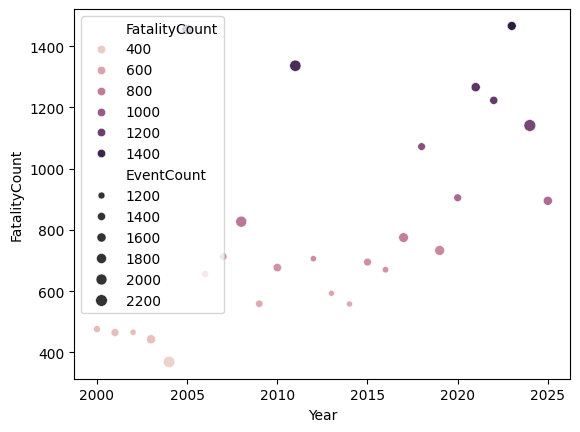

In [147]:
import seaborn as sns

sns.scatterplot(
    df,
    x = 'Year',
    y = 'FatalityCount',
    size = 'EventCount',
    hue = 'FatalityCount',

)

/var/folders/5h/3qcv61l90gd0my3rpbjkj9jr0000gn/T/ipykernel_6661/1107394411.py:94: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)


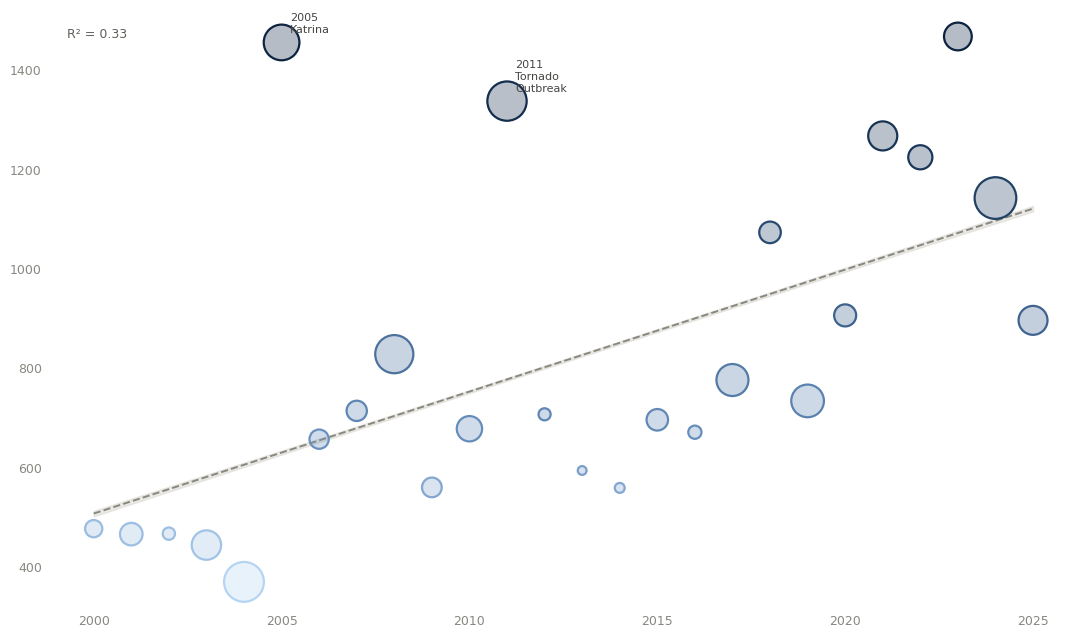

Saved.


In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from scipy import stats
from scipy import stats
import seaborn as sns


fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# --- regression line + confidence band via scipy ---
x = df['Year'].values
y = df['FatalityCount'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 300)
y_line = slope * x_line + intercept

# 95% confidence interval
n = len(x)
x_mean = x.mean()
se = std_err * np.sqrt(1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2))
t_crit = stats.t.ppf(0.975, df=n-2)
ci = t_crit * se

ax.fill_between(x_line, y_line - ci, y_line + ci, color='#D3D1C7', alpha=0.45, zorder=1)
ax.plot(x_line, y_line, color='#888780', linewidth=1.4, zorder=2, linestyle='--')

# --- bubble sizes with high contrast range ---
ec = df['EventCount'].values
size_min, size_max = 40, 900
sizes = size_min + (ec - ec.min()) / (ec.max() - ec.min()) * (size_max - size_min)

# --- edge colors: muted blue-gray → deep slate, darker = more fatalities ---
fc = df['FatalityCount'].values
norm = mcolors.Normalize(vmin=fc.min(), vmax=fc.max())
# muted palette: light dusty blue → deep blue-charcoal
cmap = mcolors.LinearSegmentedColormap.from_list(
    'fatality_muted',
    ['#B5D4F4', '#6B93C0', '#3A5F8A', '#1C3A5C', '#0C2240']
)
edge_colors = [cmap(norm(v)) for v in fc]

# --- scatter: no fill, just outlines ---
scatter = ax.scatter(
    df['Year'], df['FatalityCount'],
    s=sizes,
    facecolors=(edge_colors, 0.3),
    edgecolors=edge_colors,
    linewidths=1.6,
    zorder=3
)

# --- minimal annotation: label notable outliers ---
notable = {2005: 'Katrina', 2011: 'Tornado\nOutbreak'}
for _, row in df.iterrows():
    if row['Year'] in notable:
        label = str(int(row['Year']))
        if notable[row['Year']]:
            label += f"\n{notable[row['Year']]}"
        ax.annotate(
            label,
            xy=(row['Year'], row['FatalityCount']),
            xytext=(6, 6), textcoords='offset points',
            fontsize=8, color='#444441',
            va='bottom',
        )

# --- R² annotation ---
ax.text(0.02, 0.97, f'R² = {r_value**2:.2f}',
        transform=ax.transAxes,
        fontsize=9, color='#5F5E5A',
        va='top', ha='left')

# --- strip everything: no spines, no ticks, no box ---
for spine in ax.spines.values():
    spine.set_visible(False)

ax.xaxis.set_tick_params(length=0)
ax.yaxis.set_tick_params(length=0)
ax.tick_params(colors='#888780', labelsize=9)

# keep only bottom x-axis year labels and left y-axis labels
ax.set_xlabel('')
ax.set_ylabel('')

ax.yaxis.grid(False)
ax.xaxis.grid(False)

ax.legend().set_visible(False)

plt.tight_layout()
plt.savefig('storm_plot.png', dpi=180, bbox_inches='tight',
            transparent=True, pad_inches=0.05)
plt.show()
print("Saved.")


In [ ]:
df.corr()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
from moviepy import *
import numpy as np
import os

# ── 1. CONFIG ────────────────────────────────────────────────────────────────

FPS         = 30
CHART_W     = 1280
CHART_H     = 720
DPI         = 96
OUTPUT_FILE = "climate_story.mp4"

# Folder containing your 25 images named e.g. 2000.jpg, 2001.jpg ... 2024.jpg
IMAGE_DIR = "storm_images"

# ── 2. DATA (replace with your real data) ────────────────────────────────────

ALL_YEARS = list(range(2000, 2025))

TEMP_ANOMALY = list(df['Anomaly'])

STORM_COUNT = list(df['EventCount'])

FATALITIES = list(df['FatalityCount'])

CHARTS = [
    {"data": TEMP_ANOMALY,  "color": "#D85A30", "label": "Temperature anomaly (°C)"},
    {"data": STORM_COUNT,   "color": "#378ADD", "label": "Named storms per year"},
    {"data": FATALITIES,    "color": "#3BAD75", "label": "Storm fatalities"},
]

# ── 3. BACKGROUND PHOTO SCHEDULE ─────────────────────────────────────────────
# 25 photos (2000–2024), each on screen for a progressively shorter duration.
# We use an exponential decay so early images linger and later ones flash by.

PHOTO_YEARS  = list(range(2000, 2025))   # 25 years
TOTAL_PHOTO_DURATION = 30.0              # total seconds for all photos combined

def compute_photo_durations(years, total_secs):
    """Exponential decay: first photo longest, last photo shortest."""
    n = len(years)
    # weights decay exponentially
    weights = np.array([np.exp(-3.5 * i / (n - 1)) for i in range(n)])
    weights /= weights.sum()
    return (weights * total_secs).tolist()

PHOTO_DURATIONS = compute_photo_durations(PHOTO_YEARS, TOTAL_PHOTO_DURATION)

# ── 4. RENDER CHART ANIMATION → transparent frames ───────────────────────────

def render_chart_video(chart_cfg, out_path, total_frames):
    """
    Renders one chart as a transparent-background .mov (PNG frames via ffmpeg).
    The fill area under the line is the chart color at alpha=0.25.
    """
    years  = ALL_YEARS
    values = chart_cfg["data"]
    color  = chart_cfg["color"]
    label  = chart_cfg["label"]
    n      = len(years)

    fig, ax = plt.subplots(figsize=(CHART_W / DPI, CHART_H / DPI), dpi=DPI)
    fig.patch.set_alpha(0)
    ax.patch.set_alpha(0)

    # Style
    ax.tick_params(colors="white", labelsize=10)
    ax.yaxis.label.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.title.set_color("white")
    for spine in ax.spines.values():
        spine.set_edgecolor((1, 1, 1, 0.3))
    ax.grid(color="white", alpha=0.1, linestyle="--", linewidth=0.5)
    ax.set_title(label, color="white", fontsize=16, pad=12)

    # Pre-compute axis bounds using full dataset so they only grow, never shrink
    global_min = min(values)
    global_max = max(values)

    line,     = ax.plot([], [], color=color, linewidth=2.5, zorder=3)
    fill_poly = ax.fill_between([], [], alpha=0)   # placeholder, rebuilt each frame

    # We'll manage the fill manually with a PolyCollection
    fill_collection = [None]

    def init():
        line.set_data([], [])
        return line,

    def update(frame):
        # Map frame index → data index (so animation spans total_frames evenly)
        idx = max(1, int((frame + 1) * n / total_frames))

        x = years[:idx]
        y = values[:idx]

        line.set_data(x, y)

        # Rebuild fill under the line
        if fill_collection[0] is not None:
            fill_collection[0].remove()

        baseline = 0 if min(y) >= 0 else min(y)
        verts = list(zip(x, y)) + [(x[-1], baseline), (x[0], baseline)]
        poly  = plt.Polygon(verts, closed=True, facecolor=color,
                            alpha=0.25, zorder=2, edgecolor="none")
        ax.add_patch(poly)
        fill_collection[0] = poly

        # Dynamic axis rescaling with 15% padding
        pad_y = (max(y) - min(y)) * 0.15 or abs(max(y) * 0.1) or 0.1
        ax.set_xlim(years[0], years[-1])
        ax.set_ylim(min(y) - pad_y, max(y) + pad_y)

        return line, poly

    ani = animation.FuncAnimation(
        fig, update, frames=total_frames,
        init_func=init, blit=False, interval=1000 / FPS
    )

    # Save as PNG sequence then stitch with ffmpeg (preserves transparency)
    frame_dir = out_path.replace(".mov", "_frames")
    os.makedirs(frame_dir, exist_ok=True)

    for i in range(total_frames):
        update(i)
        fig.savefig(f"{frame_dir}/frame_{i:05d}.png",
                    transparent=True, dpi=DPI,
                    bbox_inches="tight", pad_inches=0)

    plt.close(fig)

    # Stitch frames → transparent video with ffmpeg
    os.system(
        f'ffmpeg -y -framerate {FPS} -i "{frame_dir}/frame_%05d.png" '
        f'-vcodec png -pix_fmt rgba "{out_path}"'
    )
    print(f"  Chart saved → {out_path}")


# ── 5. BUILD BACKGROUND VIDEO FROM PHOTOS ────────────────────────────────────

# Find image regardless of extension
def find_image(year):
    for ext in [".jpg", ".jpeg", ".png", ".webp"]:
        path = os.path.join(IMAGE_DIR, f"{year}{ext}")
        if os.path.exists(path):
            return path
    return None

def build_background_video(out_path):
    """
    Stacks 25 photos with progressively shorter hold times.
    Each photo crossfades into the next (0.5s crossfade).
    """
    clips = []
    for i, (year, dur) in enumerate(zip(PHOTO_YEARS, PHOTO_DURATIONS)):
        img_path = find_image(year)
        if img_path is None:
            print(f"  Warning: no image found for {year}, using black frame")

        if img_path:
            clip = (ImageClip(img_path)
                    .resize((CHART_W, CHART_H))
                    .set_duration(dur))
        else:
            clip = ColorClip((CHART_W, CHART_H), color=(0, 0, 0)).set_duration(dur)

        # Year label in corner
        label = (TextClip(str(year), fontsize=28, color="white",
                          font="DejaVu-Sans", stroke_color="black", stroke_width=1)
                 .set_position((40, 40))
                 .set_duration(dur))

        clips.append(CompositeVideoClip([clip, label])
                     .crossfadein(0.4 if i > 0 else 0))

    bg = concatenate_videoclips(clips, method="compose", padding=-0.4)
    bg.write_videofile(out_path, fps=FPS, codec="libx264",
                       audio=False, threads=4)
    print(f"  Background saved → {out_path}")
    return bg


# ── 6. COMPOSITE: BACKGROUND + THREE CHARTS ──────────────────────────────────

def build_final_video():
    os.makedirs("temp_charts", exist_ok=True)

    # Total duration driven by background photo sequence
    total_duration = sum(PHOTO_DURATIONS)
    total_frames   = int(total_duration * FPS)

    print(f"Total duration: {total_duration:.1f}s  |  Frames: {total_frames}")

    # Render each chart video
    chart_paths = []
    for cfg in CHARTS:
        safe_name = cfg["label"].replace(" ", "_").replace("(", "").replace(")", "").replace("/", "")
        path = f"temp_charts/{safe_name}.mov"
        print(f"\nRendering chart: {cfg['label']}")
        render_chart_video(cfg, path, total_frames)
        chart_paths.append(path)

    # Build background
    print("\nBuilding background video...")
    bg_path = "temp_charts/background.mp4"
    build_background_video(bg_path)

    # Load everything
    print("\nCompositing final video...")
    bg = VideoFileClip(bg_path)

    # Lay the three charts in a row across the bottom half of the frame
    # Each chart takes up 1/3 of the width, sits in the bottom 40% of the frame
    chart_w = CHART_W // 3
    chart_h = int(CHART_H * 0.40)

    chart_clips = []
    for i, path in enumerate(chart_paths):
        clip = (VideoFileClip(path, has_mask=True)
                .resize((chart_w, chart_h))
                .set_position((i * chart_w, int(CHART_H * 0.58))))
        chart_clips.append(clip)

    final = CompositeVideoClip([bg] + chart_clips, size=(CHART_W, CHART_H))
    final = final.set_duration(total_duration)

    final.write_videofile(
        OUTPUT_FILE, fps=FPS,
        codec="libx264", audio=False, threads=4,
        ffmpeg_params=["-pix_fmt", "yuv420p"]   # max compatibility
    )
    print(f"\nDone → {OUTPUT_FILE}")


if __name__ == "__main__":
    build_final_video()

In [ ]:
os.system('''
ffmpeg -y -i temp_charts/Temperature_anomaly.mov \
  -vf "scale=trunc(iw/2)*2:trunc(ih/2)*2" \
  -vcodec libx264 \
  -pix_fmt yuv420p \
  -crf 18 \
  -movflags +faststart \
  climate_story_final.mp4
''')

In [ ]:
import os
import numpy as np

IMAGE_DIR   = "storm_images"
CHART_FILE  = "temperature.mp4"
OUTPUT      = "output_final.mp4"
CHART_W, CHART_H = 1280, 720
TOTAL_DURATION   = 30.0

photo_years = list(range(2000, 2025))

def find_image(year):
    for ext in [".jpg", ".jpeg", ".png", ".webp"]:
        path = os.path.join(IMAGE_DIR, f"{year}{ext}")
        if os.path.exists(path):
            return path
    return None

images = [(y, find_image(y)) for y in photo_years if find_image(y)]

n       = len(images)
weights = np.array([np.exp(-3.5 * i / (n - 1)) for i in range(n)])
weights /= weights.sum()
durations = (weights * TOTAL_DURATION).tolist()

# ── Build filter string ───────────────────────────────────────────────────────
lines = []

# Scale each image
for i in range(n):
    lines.append(
        f"[{i}]scale={CHART_W}:{CHART_H}:force_original_aspect_ratio=decrease,"
        f"pad={CHART_W}:{CHART_H}:(ow-iw)/2:(oh-ih)/2[bg{i}]"
    )

# Chain xfades
fade_dur   = 0.4
cumulative = 0.0
for i in range(1, n):
    cumulative += durations[i - 1]
    offset = max(0, cumulative - fade_dur)
    src_a  = "bg0"   if i == 1 else f"x{i-1}"
    out    = "bg"    if i == n - 1 else f"x{i}"
    lines.append(
        f"[{src_a}][bg{i}]xfade=transition=fade:duration={fade_dur}:offset={offset:.2f}[{out}]"
    )

# Overlay chart on top
lines.append(f"[bg][{n}]overlay=0:0[out]")

filter_str = ";\n".join(lines)

# Write filter to a temp file — avoids ALL shell escaping problems
filter_file = "temp_filter.txt"
with open(filter_file, "w") as f:
    f.write(filter_str)

# ── Build input args ──────────────────────────────────────────────────────────
input_args = ""
for _, path in images:
    input_args += f'-loop 1 -i "{path}" '
input_args += f'-i "{CHART_FILE}"'

cmd = (
    f'ffmpeg -y {input_args} '
    f'-filter_complex_script "{filter_file}" '
    f'-map "[out]" '
    f'-vcodec libx264 -pix_fmt yuv420p -crf 18 -movflags +faststart '
    f'"{OUTPUT}"'
)

print(cmd)
os.system(cmd)


In [68]:
df_fatalities.columns

Index(['FAT_YEARMONTH', 'FAT_DAY', 'FAT_TIME', 'FATALITY_ID', 'EVENT_ID',
       'FATALITY_TYPE', 'FATALITY_DATE', 'FATALITY_AGE', 'FATALITY_SEX',
       'FATALITY_LOCATION', 'Year'],
      dtype='str')

In [70]:
df_fatalities.groupby(['Year', 'EVENT_ID']).size().reset_index()

,Year,EVENT_ID,0
0,2000,5126831,1
1,2000,5126839,1
2,2000,5126858,1
3,2000,5126874,2
4,2000,5127159,1
...,...,...,...
11827,2025,1307799,3
11828,2025,1307818,1
11829,2025,1307988,1
11830,2025,1308132,1


In [74]:
event_nos = list(df_events_short['EVENT_ID'])

fatal_events = df_fatalities[df_fatalities['EVENT_ID'].isin(event_nos)]
fatal_events

,FAT_YEARMONTH,FAT_DAY,FAT_TIME,FATALITY_ID,EVENT_ID,FATALITY_TYPE,FATALITY_DATE,FATALITY_AGE,FATALITY_SEX,FATALITY_LOCATION,Year
131,200211,12,0,19713,5323812,D,11/12/2002 12:00:00,42.0,M,Mobile/Trailer Home,2002
132,200211,9,0,19714,5323812,D,11/09/2002 12:00:00,65.0,F,Mobile/Trailer Home,2002
134,200211,10,0,19716,5322729,D,11/10/2002 12:00:00,47.0,M,Permanent Home,2002
135,200211,10,0,19717,5322729,D,11/10/2002 12:00:00,36.0,F,Permanent Home,2002
136,200211,10,0,19718,5322729,D,11/10/2002 12:00:00,73.0,F,Permanent Home,2002
...,...,...,...,...,...,...,...,...,...,...,...
21110,200305,4,0,20044,5358086,D,05/04/2003 12:00:00,87.0,F,Permanent Home,2003
21111,200305,4,0,20050,5358167,D,05/04/2003 12:00:00,40.0,M,Permanent Home,2003
21112,200305,4,0,20056,5358178,D,05/04/2003 12:00:00,62.0,F,Permanent Home,2003
21124,200309,18,0,20289,5370978,D,09/18/2003 12:00:00,32.0,F,Vehicle/Towed Trailer,2003


In [102]:
fatal_event = fatal_events.groupby(['EVENT_ID']).size().reset_index()

In [103]:
fatal_event = fatal_event.merge(df_events[['EVENT_ID', 'EVENT_TYPE']], on = 'EVENT_ID', how='left')
fatal_event = fatal_event.merge(df_events[['EVENT_ID', 'BEGIN_YEARMONTH','Year']], on = 'EVENT_ID', how='left')
fatal_event.rename(columns={0:'Fatalities'}, inplace=True)
fatal_event

,EVENT_ID,Fatalities,EVENT_TYPE,BEGIN_YEARMONTH,Year
0,3485,8,Tornado,200611,2006
1,6054,1,Tornado,200611,2006
2,6219,1,Tornado,200611,2006
3,6358,1,Tornado,200612,2006
4,7011,1,Tornado,200612,2006
...,...,...,...,...,...
754,5506369,6,Tornado,200604,2006
755,5506443,2,Tornado,200604,2006
756,5511066,2,Tornado,200605,2006
757,5511067,1,Tornado,200605,2006


In [104]:
fatal_event.sort_values('Fatalities', ascending=False, inplace=True)
fatal_event

,EVENT_ID,Fatalities,EVENT_TYPE,BEGIN_YEARMONTH,Year
717,5475622,638,Hurricane (Typhoon),200508,2005
140,296617,161,Tornado,201105,2011
716,5475620,140,Hurricane (Typhoon),200508,2005
722,5475640,97,Hurricane (Typhoon),200508,2005
470,1058654,60,Hurricane (Typhoon),202209,2022
...,...,...,...,...,...
466,1057264,1,Tornado,202211,2022
202,314923,1,Tornado,201104,2011
464,1014520,1,Tornado,202204,2022
463,1014168,1,Tornado,202203,2022


In [129]:
fatal_event_year = fatal_event.groupby(['Year','EVENT_TYPE']).sum().reset_index()

In [134]:
fatal_event_year['Year'] = pd.to_numeric(fatal_event_year['Year'])

In [135]:
fatal_event_year

,Year,EVENT_TYPE,BEGIN_YEARMONTH,EVENT_ID,Fatalities
0,2000,Tornado,1400042,72087465,41
1,2001,Hurricane (Typhoon),200112,5275807,1
2,2001,Tornado,1600850,99899488,28
3,2002,Hurricane (Typhoon),200212,5324056,1
4,2002,Tornado,1001042,148794113,55
5,2003,Hurricane (Typhoon),200309,32196967,6
6,2003,Tornado,1201837,112452081,51
7,2004,Hurricane (Typhoon),400817,54202592,23
8,2004,Tornado,1402853,108261219,36
9,2005,Hurricane (Typhoon),802034,158759432,1016


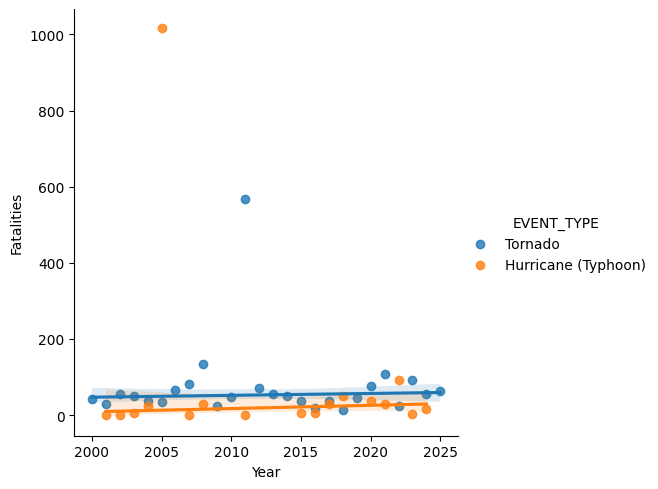

In [138]:
import seaborn as sns

sns.lmplot(
    data = fatal_event_year,
    x='Year',
    y='Fatalities',
    hue = 'EVENT_TYPE',
    robust = True
)

<Axes: xlabel='Year', ylabel='Count'>

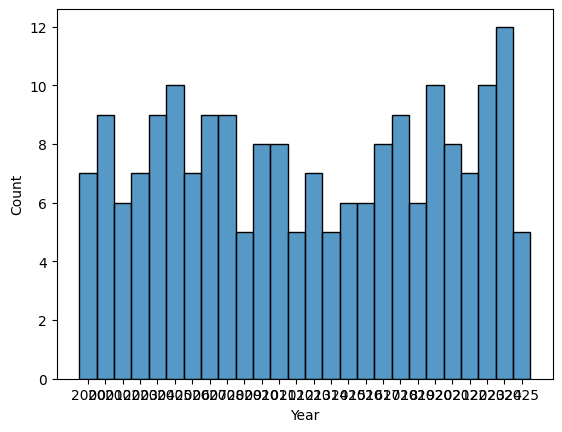

In [189]:
import seaborn as sns

sns.histplot(
    data = fatal_event,
    x = 'Year'
)

In [166]:
df

,Year,EventCount,FatalityCount,Anomaly,FatalityPerEvent
0,2000,1211,476,0.390000,0.393064
1,2001,1360,465,0.530000,0.341912
2,2002,1108,466,0.625000,0.420578
3,2003,1611,443,0.613333,0.274984
4,2004,2118,369,0.526667,0.174221
5,2005,1898,1454,0.674167,0.766070
6,2006,1263,656,0.637500,0.519398
7,2007,1291,713,0.662500,0.552285
8,2008,2026,827,0.538333,0.408193
9,2009,1274,559,0.651667,0.438776


In [165]:
df['FatalityPerEvent'] = df['FatalityCount'] / df['EventCount']

<Axes: xlabel='Year', ylabel='EventCount'>

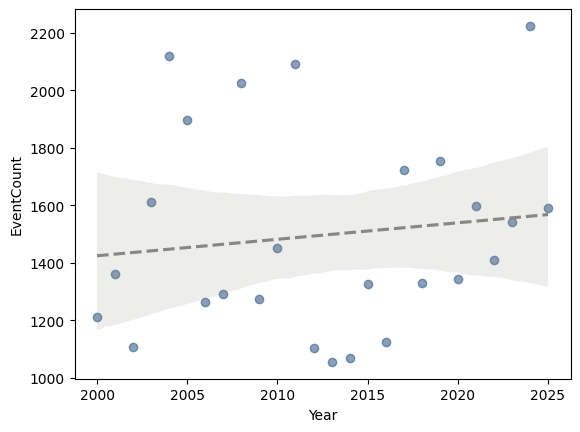

In [186]:
fig, ax = plt.subplots()

sns.regplot(
    data=df,
    x='Year',
    y='EventCount',
    ax=ax,
    scatter_kws={'alpha': 0.6, 'color': '#3A5F8A'},   # style the dots
    line_kws={'color': '#888780', 'linestyle': '--'},   # style the regression line
    ci=95,                                              # confidence interval (default is 95)
)

/var/folders/5h/3qcv61l90gd0my3rpbjkj9jr0000gn/T/ipykernel_6661/1033350370.py:73: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend().set_visible(False)


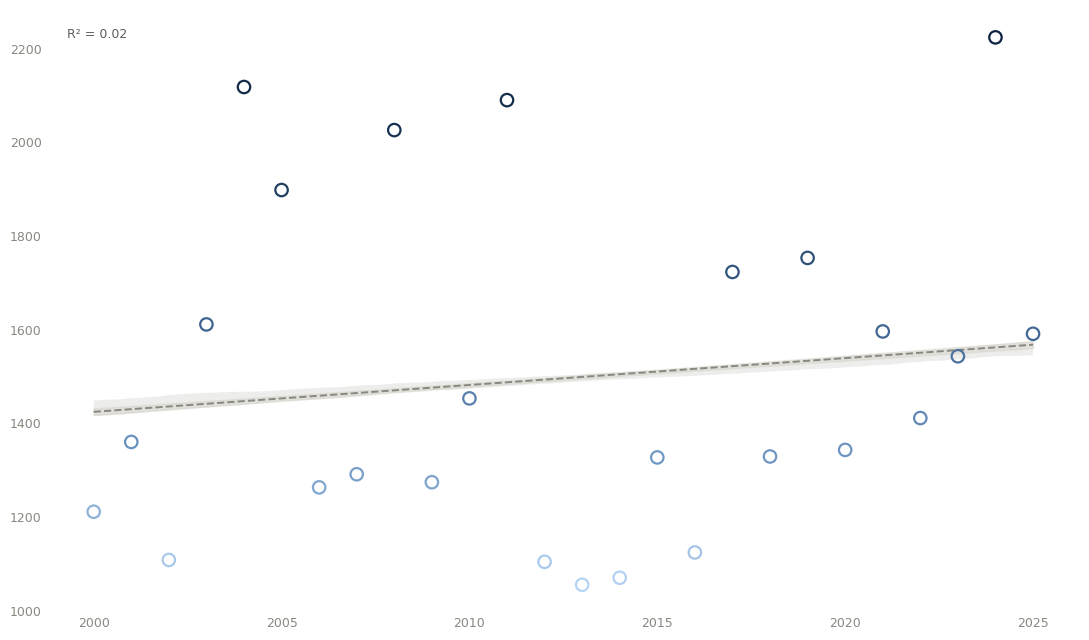

Saved.


In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats
import seaborn as sns

fig, ax = plt.subplots(figsize=(11, 6.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# --- regplot: confidence band + regression line styled to match bubble chart ---
sns.regplot(
    data=df,
    x='Year',
    y='EventCount',
    ax=ax,
    ci=10,
    scatter=False,                                          # we'll draw scatter manually for color control
    line_kws={'color': '#888780', 'linewidth': 1.4, 'linestyle': '--', 'zorder': 2},
    )

# redraw the confidence band to match bubble chart color
x = df['Year'].values
y = df['EventCount'].values
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 300)
y_line = slope * x_line + intercept
n = len(x)
x_mean = x.mean()
se = std_err * np.sqrt(1/n + (x_line - x_mean)**2 / np.sum((x - x_mean)**2))
t_crit = stats.t.ppf(0.975, df=n-2)
ci = t_crit * se
ax.fill_between(x_line, y_line - ci, y_line + ci, color='#D3D1C7', alpha=0.45, zorder=1)

# --- edge colors: muted blue → deep navy, darker = more events ---
ec = df['EventCount'].values
norm = mcolors.Normalize(vmin=ec.min(), vmax=ec.max())
cmap = mcolors.LinearSegmentedColormap.from_list(
    'event_muted',
    ['#B5D4F4', '#6B93C0', '#3A5F8A', '#1C3A5C', '#0C2240']
)
edge_colors = [cmap(norm(v)) for v in ec]

# --- scatter: hollow circles, edge color by EventCount ---
ax.scatter(
    df['Year'], df['EventCount'],
    s=80,
    facecolors='none',
    edgecolors=edge_colors,
    linewidths=1.6,
    zorder=3,
)

# --- R² annotation ---
ax.text(0.02, 0.97, f'R² = {r_value**2:.2f}',
        transform=ax.transAxes,
        fontsize=9, color='#5F5E5A',
        va='top', ha='left')

# --- strip everything: no spines, no ticks, no box ---
for spine in ax.spines.values():
    spine.set_visible(False)

ax.xaxis.set_tick_params(length=0)
ax.yaxis.set_tick_params(length=0)
ax.tick_params(colors='#888780', labelsize=9)

ax.set_xlabel('')
ax.set_ylabel('')
ax.yaxis.grid(False)
ax.xaxis.grid(False)
ax.legend().set_visible(False)

plt.tight_layout()
plt.savefig('storm_regplot.png', dpi=180, bbox_inches='tight',
             transparent=True)
plt.show()
print("Saved.")


In [91]:
df

,Year,EventCount,FatalityCount,Anomaly
0,2000,1211,476,0.390000
1,2001,1360,465,0.530000
2,2002,1108,466,0.625000
3,2003,1611,443,0.613333
4,2004,2118,369,0.526667
5,2005,1898,1454,0.674167
6,2006,1263,656,0.637500
7,2007,1291,713,0.662500
8,2008,2026,827,0.538333
9,2009,1274,559,0.651667


In [92]:
temp_anomaly = df['Anomaly']
years = df['Year']
storms = df['EventCount']

In [94]:
import numpy as np
corr = np.corrcoef(temp_anomaly, storms)[0,1]
print(f"Correlation: {corr:.3f}")

Correlation: 0.158


In [96]:
temp_diff = np.diff(temp_anomaly)
storm_diff = np.diff(storms)
corr_diff = np.corrcoef(temp_diff, storm_diff)[0,1]
print(f"Correlation: {corr_diff:.3f}")

Correlation: -0.153


In [98]:
df_events

,index,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,...,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,Year
0,975480,200001,3,1405,200001,3,1405,1090502,5129129,INDIANA,...,N,FREDDRICKSBURG,NaN,NaN,NaN,NaN,NaN,A tornado touched down in Washington county no...,PDC,2000
1,977837,200001,3,1330,200001,3,1340,1090549,5129620,MISSISSIPPI,...,E,WATER VLY,34.16667,-89.55000,34.23333,-89.55000,NaN,The tornado first developed just south of High...,PDC,2000
2,977860,200001,3,1340,200001,3,1400,1090549,5129728,MISSISSIPPI,...,W,PARIS,34.18333,-89.51667,34.38333,-89.26667,NaN,The tornado first developed just south of High...,PDC,2000
3,977514,200001,3,1400,200001,3,1410,1090549,5129729,MISSISSIPPI,...,SW,PINEDALE,34.38333,-89.25000,34.60000,-89.08333,NaN,The tornado first developed just south of High...,PDC,2000
4,978353,200001,3,1215,200001,3,1218,1090744,5131031,MISSISSIPPI,...,SW,SCHLATER,33.63333,-90.36667,33.66667,-90.33333,NaN,This weak tornado nearly destroyed a mobile ho...,PDC,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38891,185502,202512,28,1645,202512,28,1646,209460,1305604,ILLINOIS,...,SE,REDMON,39.63430,-87.84450,39.63480,-87.84080,The airmass continued to destabilize across ce...,Video evidence indicated that a tornado touche...,CSV,2025
38892,185503,202512,28,1459,202512,28,1500,209460,1305605,ILLINOIS,...,SE,OSBERNVILLE,39.71440,-89.14210,39.71520,-89.14030,The airmass continued to destabilize across ce...,A storm spotter captured video of a tornado to...,CSV,2025
38893,185692,202512,28,1500,202512,28,1530,209460,1305606,ILLINOIS,...,ENE,CASNER,39.71520,-89.14030,39.82270,-88.74610,The airmass continued to destabilize across ce...,This tornado crossed into far western Macon Co...,CSV,2025
38894,185693,202512,28,1530,202512,28,1533,209460,1305607,ILLINOIS,...,NNW,LA PLACE,39.82270,-88.74610,39.82550,-88.72680,The airmass continued to destabilize across ce...,This tornado crossed into western Piatt County...,CSV,2025


In [99]:
df_events

,index,BEGIN_YEARMONTH,BEGIN_DAY,BEGIN_TIME,END_YEARMONTH,END_DAY,END_TIME,EPISODE_ID,EVENT_ID,STATE,...,END_AZIMUTH,END_LOCATION,BEGIN_LAT,BEGIN_LON,END_LAT,END_LON,EPISODE_NARRATIVE,EVENT_NARRATIVE,DATA_SOURCE,Year
0,975480,200001,3,1405,200001,3,1405,1090502,5129129,INDIANA,...,N,FREDDRICKSBURG,NaN,NaN,NaN,NaN,NaN,A tornado touched down in Washington county no...,PDC,2000
1,977837,200001,3,1330,200001,3,1340,1090549,5129620,MISSISSIPPI,...,E,WATER VLY,34.16667,-89.55000,34.23333,-89.55000,NaN,The tornado first developed just south of High...,PDC,2000
2,977860,200001,3,1340,200001,3,1400,1090549,5129728,MISSISSIPPI,...,W,PARIS,34.18333,-89.51667,34.38333,-89.26667,NaN,The tornado first developed just south of High...,PDC,2000
3,977514,200001,3,1400,200001,3,1410,1090549,5129729,MISSISSIPPI,...,SW,PINEDALE,34.38333,-89.25000,34.60000,-89.08333,NaN,The tornado first developed just south of High...,PDC,2000
4,978353,200001,3,1215,200001,3,1218,1090744,5131031,MISSISSIPPI,...,SW,SCHLATER,33.63333,-90.36667,33.66667,-90.33333,NaN,This weak tornado nearly destroyed a mobile ho...,PDC,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38891,185502,202512,28,1645,202512,28,1646,209460,1305604,ILLINOIS,...,SE,REDMON,39.63430,-87.84450,39.63480,-87.84080,The airmass continued to destabilize across ce...,Video evidence indicated that a tornado touche...,CSV,2025
38892,185503,202512,28,1459,202512,28,1500,209460,1305605,ILLINOIS,...,SE,OSBERNVILLE,39.71440,-89.14210,39.71520,-89.14030,The airmass continued to destabilize across ce...,A storm spotter captured video of a tornado to...,CSV,2025
38893,185692,202512,28,1500,202512,28,1530,209460,1305606,ILLINOIS,...,ENE,CASNER,39.71520,-89.14030,39.82270,-88.74610,The airmass continued to destabilize across ce...,This tornado crossed into far western Macon Co...,CSV,2025
38894,185693,202512,28,1530,202512,28,1533,209460,1305607,ILLINOIS,...,NNW,LA PLACE,39.82270,-88.74610,39.82550,-88.72680,The airmass continued to destabilize across ce...,This tornado crossed into western Piatt County...,CSV,2025


In [122]:
event_separate_count = df_events.groupby(['Year','EVENT_TYPE']).count().reset_index().rename(columns={'EVENT_ID':'EventCount'})
df_separate = event_separate_count[['Year','EVENT_TYPE', 'EventCount']]
df_sep_wide = df_separate.pivot(
    index='Year',
    columns='EVENT_TYPE',
    values='EventCount',
).reset_index()
df_sep_wide.fillna(0, inplace=True)
df_sep_wide['Hurricane'] = df_sep_wide['Hurricane (Typhoon)'] + df_sep_wide['Marine Hurricane/Typhoon']
df_sep_wide  = df_sep_wide[['Year','Tornado','Hurricane']]
df_sep_wide['temp_anomaly'] = df['Anomaly']
df_sep_wide

EVENT_TYPE,Year,Tornado,Hurricane,temp_anomaly
0,2000,1169.0,42.0,0.390000
1,2001,1351.0,9.0,0.530000
2,2002,1040.0,68.0,0.625000
3,2003,1535.0,76.0,0.613333
4,2004,1947.0,171.0,0.526667
5,2005,1343.0,555.0,0.674167
6,2006,1263.0,0.0,0.637500
7,2007,1242.0,49.0,0.662500
8,2008,1954.0,72.0,0.538333
9,2009,1273.0,1.0,0.651667


In [129]:
from sklearn.linear_model import LinearRegression

temp_anomaly = df_sep_wide['temp_anomaly']
hurricanes = df_sep_wide['Hurricane']
tornados = df_sep_wide['Tornado']

X = np.array(temp_anomaly).reshape(-1, 1)
y = tornados+hurricanes

model = LinearRegression().fit(X,y)
print('Slope:', model.coef_[0])
print('R2:', model.score(X,y))

Slope: 242.5778974052842
R2: 0.025039065730668164


In [148]:
temp_diff = np.diff(temp_anomaly)
hurr_diff = np.diff(hurricanes)
torn_diff = np.diff(tornados)
total_diff = hurr_diff + torn_diff
print(np.corrcoef(temp_diff, hurr_diff)[0,1])
print(np.corrcoef(temp_diff[:-1], torn_diff[1:])[0,1])
print(np.corrcoef(temp_diff[:-1], total_diff[1:])[0,1])

0.1994725005059592
0.3857886969593812
0.3153326362733407


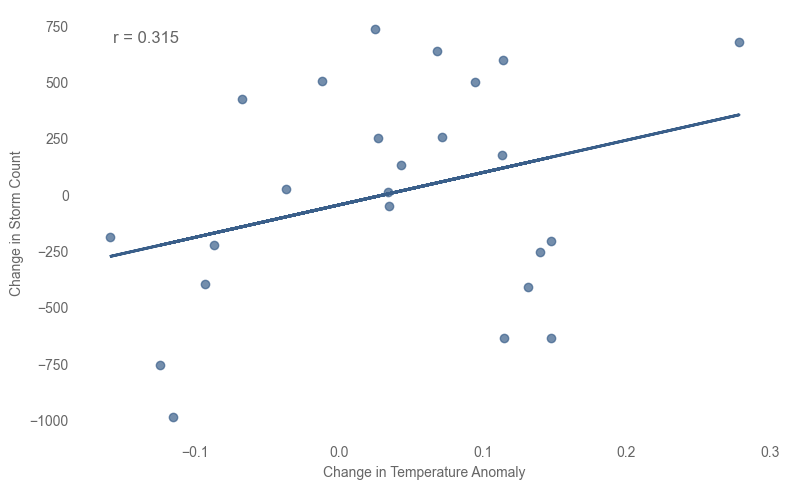

In [163]:
import numpy as np
import matplotlib.pyplot as plt

# --- differenced data ---
temp_diff = np.diff(temp_anomaly)
storm_diff = np.diff(df_sep_wide['Tornado']+df_sep_wide['Hurricane'])

# --- align correctly ---
x = temp_diff[:-1]
y = storm_diff[1:]

# --- correlation ---
r = np.corrcoef(x, y)[0, 1]

# --- regression ---
m, b = np.polyfit(x, y, 1)

# --- plot ---
fig, ax = plt.subplots(figsize=(8, 5))

# transparent background
fig.patch.set_alpha(0)
ax.set_facecolor('none')

# scatter
ax.scatter(x, y, alpha=0.7, color='#3A5F8A')

# regression line
ax.plot(x, m * np.array(x) + b, color='#3A5F8A', linewidth=2)

# labels (medium gray)
label_color = '#666666'
tick_color = '#666666'

ax.set_xlabel("Change in Temperature Anomaly", color=label_color)
ax.set_ylabel("Change in Storm Count", color=label_color)

ax.tick_params(axis='both', colors=tick_color)

# remove grid + spines
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

# correlation text (top-left of plot)
ax.text(
    0.05, 0.95,
    f"r = {r:.3f}",
    transform=ax.transAxes,
    fontsize=12,
    color=label_color,
    verticalalignment='top'
)

plt.tight_layout()
plt.show()